# ECG Model Comparison — DAT255

Deep comparison of the models trained by `training.ipynb`. This notebook
**never retrains** — it loads the saved `artifacts/` and analyses them.

Four variants are compared: CNN (aug/no-aug) × BiLSTM (aug/no-aug). The aug/no-aug
pairs let us ablate whether data augmentation actually helps on this dataset.

**Comparisons covered**:
1. Training dynamics (aug vs no-aug, per architecture)
2. Standard multi-label metrics at threshold 0.5
3. Per-class precision / recall / F1
4. ROC & PR curves per class
5. Per-class threshold optimisation (val-selected, test-evaluated)
6. Confusion matrices at optimised thresholds
7. Bootstrap 95% CIs on macro-F1
8. Augmentation ablation — paired deltas with bootstrap significance
9. Grad-CAM on the best single model
10. External context — Strodthoff et al. benchmark numbers


## 1. Load artifacts

In [2]:
import os, pickle, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras
import tensorflow as tf
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, multilabel_confusion_matrix,
    accuracy_score,
)

os.environ["KERAS_BACKEND"] = "tensorflow"
ART_DIR = "artifacts"
SUPERCLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]
NUM_CLASSES = len(SUPERCLASSES)

# Load val + test sets (val is used for threshold selection, test for final eval)
data = np.load(os.path.join(ART_DIR, "eval_sets.npz"))
X_val,  y_val  = data["X_val"],  data["y_val"]
X_test, y_test = data["X_test"], data["y_test"]

# Load models — four variants
MODEL_NAMES = ["cnn_aug", "cnn_noaug", "lstm_aug", "lstm_noaug"]
MODEL_LABELS = {
    "cnn_aug":    "1D-CNN (aug)",
    "cnn_noaug":  "1D-CNN (no aug)",
    "lstm_aug":   "BiLSTM (aug)",
    "lstm_noaug": "BiLSTM (no aug)",
}

def _path(name):
    """ecg_cnn_aug_final.keras etc. -- matches naming in training.ipynb."""
    base, suffix = name.rsplit("_", 1)  # ("cnn", "aug")
    return os.path.join(ART_DIR, f"ecg_{base}_{suffix}_final.keras")

models = {name: keras.saving.load_model(_path(name), compile=False)
          for name in MODEL_NAMES}

# Load histories + tuner results
with open(os.path.join(ART_DIR, "histories.pkl"), "rb") as f:
    histories = pickle.load(f)

tuner_path = os.path.join(ART_DIR, "tuner_results.json")
if os.path.exists(tuner_path):
    with open(tuner_path) as f:
        tuner_results = json.load(f)
    print("Keras Tuner best hyperparameters:")
    for k, v in tuner_results.items():
        print(f"  {k:15s} = {v}")
else:
    tuner_results = None

print(f"\nTest set: {X_test.shape}   Models loaded: {list(models.keys())}")


Keras Tuner best hyperparameters:
  filters_mult    = 2.0
  dropout         = 0.3
  dense_units     = 128
  lr              = 0.0004098521113058352
  loss            = bce

Test set: (2126, 1000, 12)   Models loaded: ['cnn_aug', 'cnn_noaug', 'lstm_aug', 'lstm_noaug']


## 1b. Model architecture diagrams

Render each loaded model with `keras.utils.plot_model` so the architectural
differences (CNN vs BiLSTM, aug vs no-aug share architecture) are visible
in the report. PNGs are saved to `artifacts/` for inclusion in writeups.

1D-CNN (aug)  (cnn_1d)  ->  artifacts/model_structure_cnn_aug.png


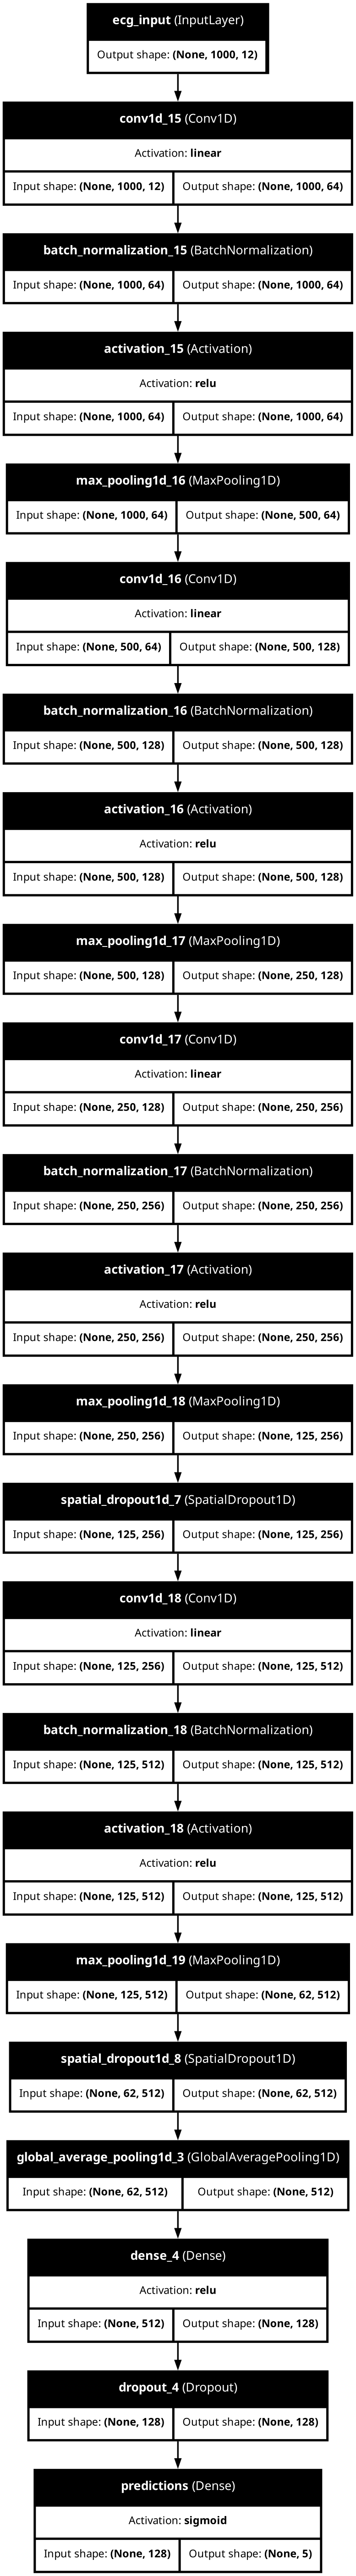

1D-CNN (no aug)  (cnn_1d)  ->  artifacts/model_structure_cnn_noaug.png


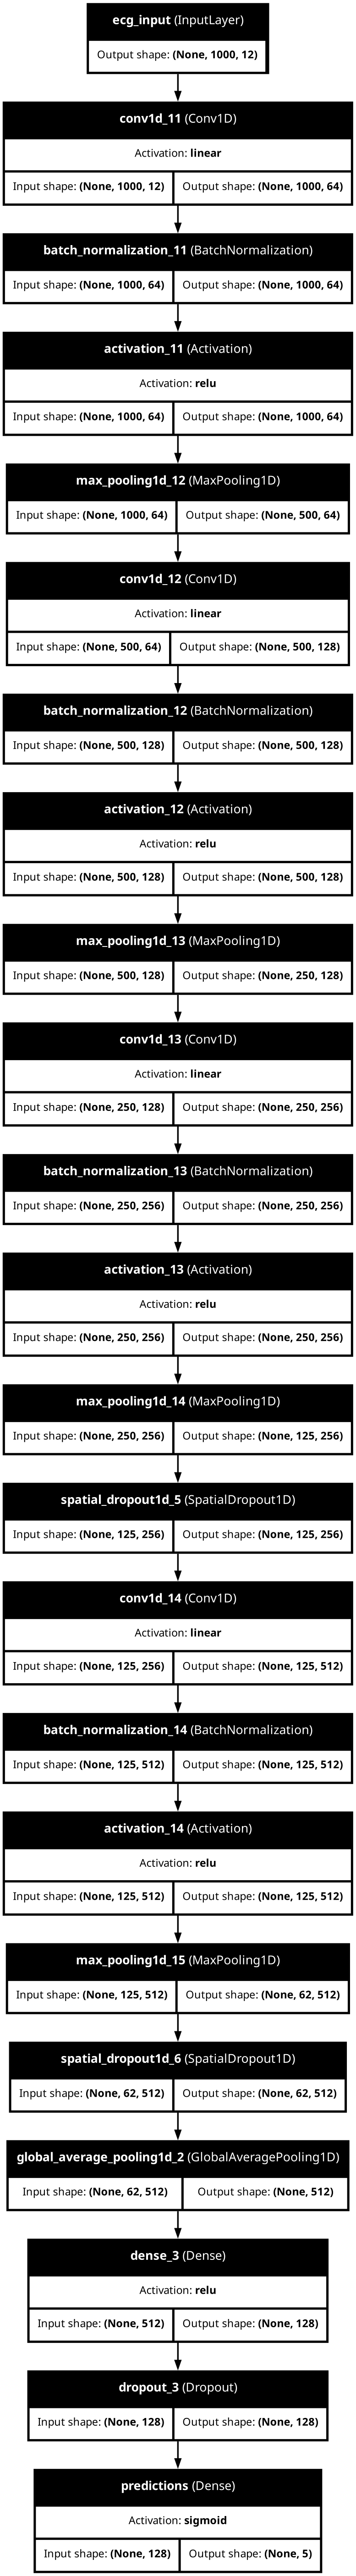

BiLSTM (aug)  (bilstm)  ->  artifacts/model_structure_lstm_aug.png


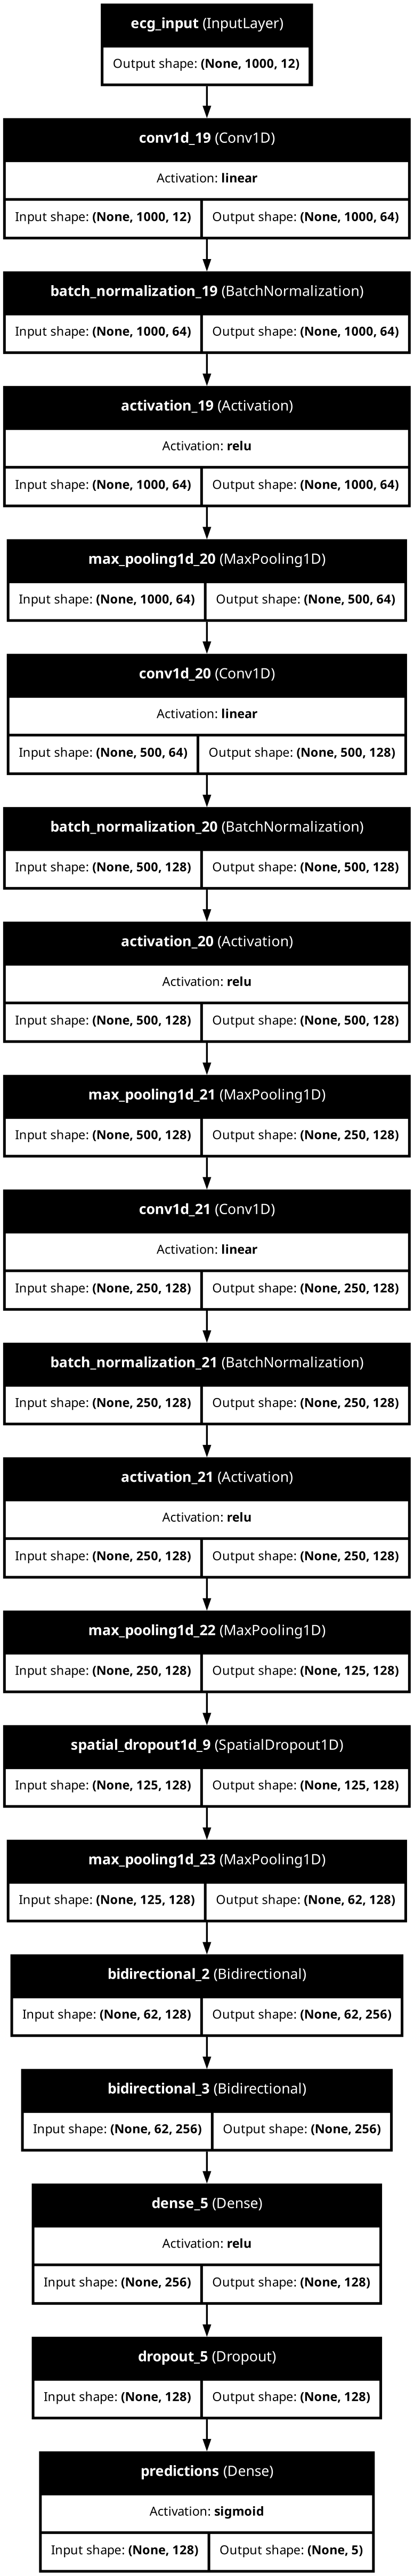

BiLSTM (no aug)  (bilstm)  ->  artifacts/model_structure_lstm_noaug.png


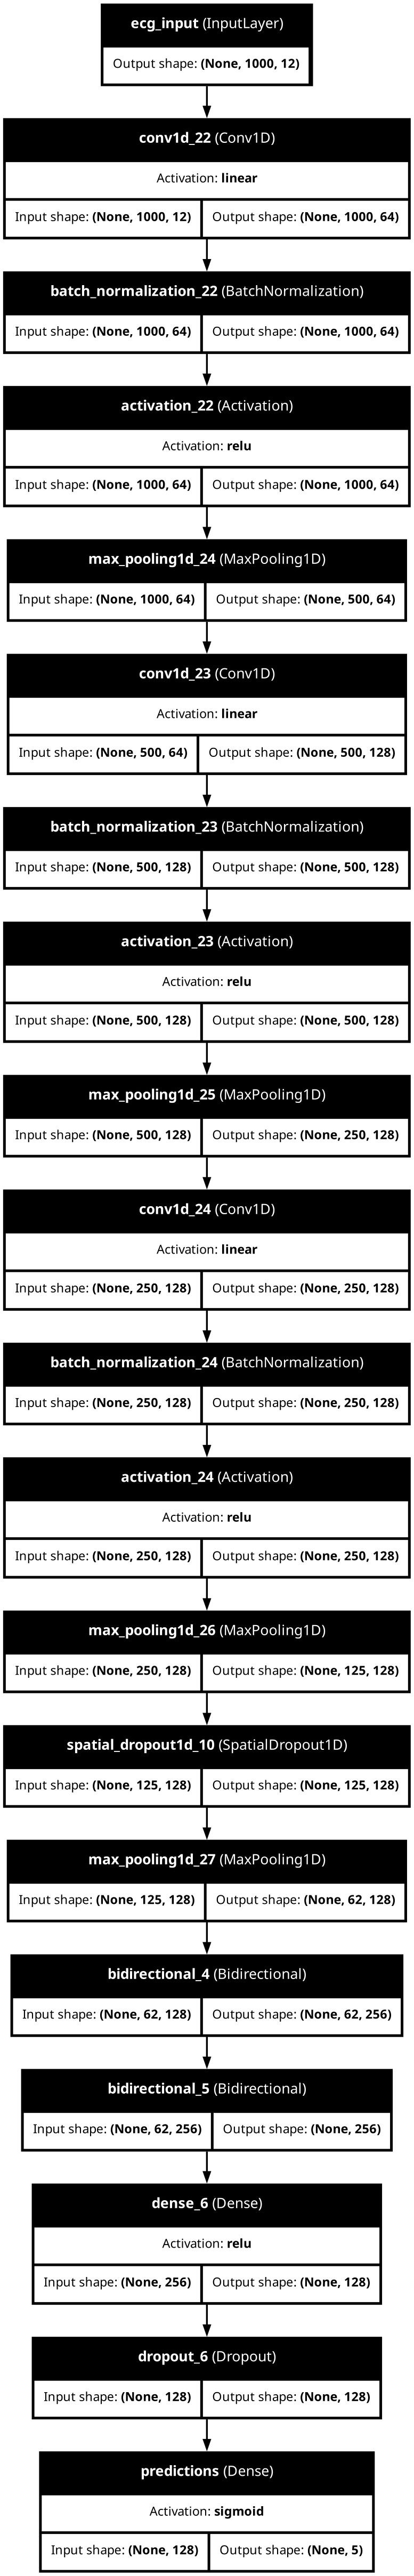

In [3]:
from IPython.display import Image, display

for name, model in models.items():
    out_path = os.path.join(ART_DIR, f"model_structure_{name}.png")
    keras.utils.plot_model(
        model,
        to_file=out_path,
        show_shapes=True,
        show_layer_names=True,
        show_layer_activations=True,
        dpi=120,
    )
    print(f"{MODEL_LABELS[name]}  ({model.name})  ->  {out_path}")
    display(Image(out_path))

## 2. Run inference for all models

In [4]:
probs_val = {
    name: m.predict(X_val, batch_size=128, verbose=0)
    for name, m in models.items()
}
probs = {
    name: m.predict(X_test, batch_size=128, verbose=0)
    for name, m in models.items()
}
for name in MODEL_NAMES:
    print(f"{name:12s}  val={probs_val[name].shape}  test={probs[name].shape}")


I0000 00:00:1777118986.742342   15227 service.cc:153] XLA service 0x568ac9f60010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777118986.742379   15227 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1777118986.769530   15227 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777118986.820544   15227 cuda_dnn.cc:461] Loaded cuDNN version 92000
W0000 00:00:1777118987.404078   15321 hlo_rematerialization.cc:3204] Can't reduce memory use below 9.10GiB (9772796478 bytes) by rematerialization; only reduced to 24.22GiB (26004553760 bytes), down from 24.22GiB (26004553760 bytes) originally
W0000 00:00:1777118997.510582   15227 bfc_allocator.cc:502] Allocator (GPU_0_bfc) ran out of memory trying to allocate 24.19GiB (rounded to 25971786240)requested by o

cnn_aug       val=(2105, 5)  test=(2126, 5)
cnn_noaug     val=(2105, 5)  test=(2126, 5)
lstm_aug      val=(2105, 5)  test=(2126, 5)
lstm_noaug    val=(2105, 5)  test=(2126, 5)


## 3. Training curves — aug vs no-aug per architecture

Side-by-side training dynamics. Watch for: (a) overfitting gap between
train/val, (b) whether augmentation shrinks that gap, (c) final val-AUC delta.


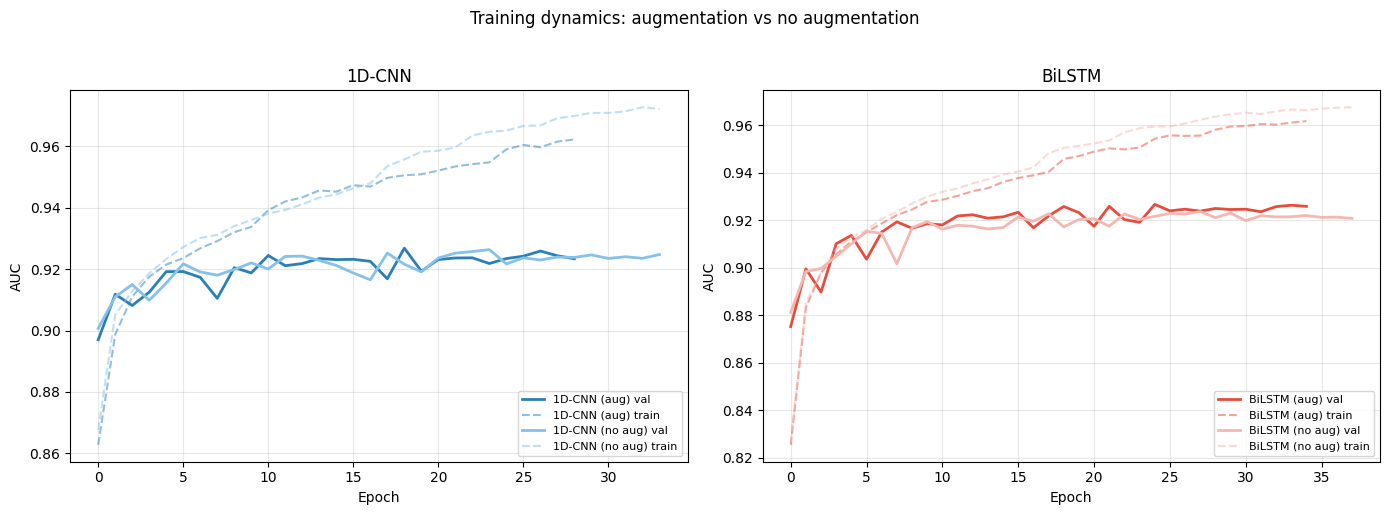

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ARCH_COLORS = {
    "cnn_aug":    "#2980b9",
    "cnn_noaug":  "#85c1e9",
    "lstm_aug":   "#e74c3c",
    "lstm_noaug": "#f5b7b1",
}

# One axis per architecture so aug/noaug overlay cleanly
for ax, arch in zip(axes, ["cnn", "lstm"]):
    for suffix in ["aug", "noaug"]:
        key = f"{arch}_{suffix}"
        if key not in histories:
            continue
        h = histories[key]
        color = ARCH_COLORS[key]
        if "val_auc" in h:
            ax.plot(h["val_auc"],
                    label=f"{MODEL_LABELS[key]} val",   color=color, lw=2)
        if "auc" in h:
            ax.plot(h["auc"],
                    label=f"{MODEL_LABELS[key]} train", color=color, ls="--", alpha=0.5)
    ax.set_title("1D-CNN" if arch == "cnn" else "BiLSTM")
    ax.set_xlabel("Epoch"); ax.set_ylabel("AUC")
    ax.grid(alpha=0.3); ax.legend(fontsize=8, loc="lower right")

plt.suptitle("Training dynamics: augmentation vs no augmentation", y=1.02)
plt.tight_layout(); plt.savefig("curves_comparison.png", dpi=150); plt.show()


## 4. Standard metrics at threshold 0.5

In [6]:
def evaluate_at_threshold(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(np.float32)
    return {
        "f1_macro":   f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro":   f1_score(y_true, y_pred, average="micro", zero_division=0),
        "f1_weighted":f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "auc_macro":  roc_auc_score(y_true, y_prob, average="macro"),
        "auc_micro":  roc_auc_score(y_true, y_prob, average="micro"),
        "ap_macro":   average_precision_score(y_true, y_prob, average="macro"),
        "subset_acc": accuracy_score(y_true, y_pred),
    }

rows = []
for name, p in probs.items():
    r = evaluate_at_threshold(y_test, p, 0.5)
    r["model"] = MODEL_LABELS[name]
    rows.append(r)

summary_05 = pd.DataFrame(rows).set_index("model")
summary_05 = summary_05[["f1_macro","f1_micro","f1_weighted",
                         "auc_macro","auc_micro","ap_macro","subset_acc"]]
print("Metrics at threshold=0.5:")
display(summary_05.round(4))

Metrics at threshold=0.5:


,f1_macro,f1_micro,f1_weighted,auc_macro,auc_micro,ap_macro,subset_acc
model,,,,,,,
1D-CNN (aug),0.7278,0.7626,0.7605,0.9240,0.9343,0.8129,0.6101
1D-CNN (no aug),0.7291,0.7724,0.7660,0.9243,0.9355,0.8124,0.6322
BiLSTM (aug),0.7285,0.7697,0.7629,0.9247,0.9348,0.8151,0.6345
BiLSTM (no aug),0.7306,0.7693,0.7649,0.9198,0.9332,0.8104,0.6265


## 5. Per-class precision / recall / F1 (threshold 0.5)

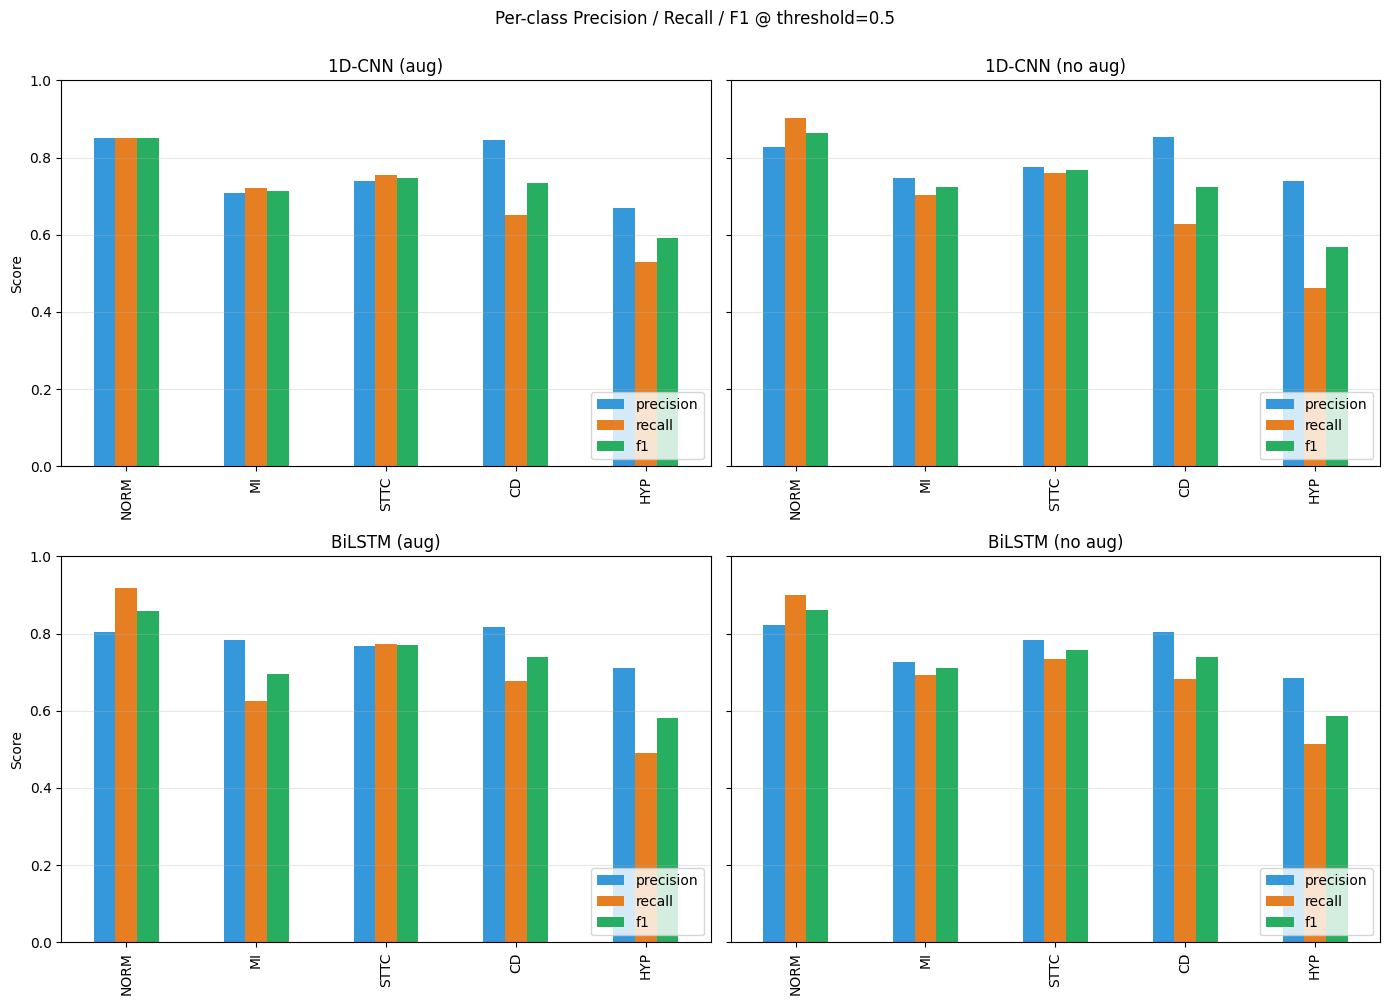

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
axes = axes.flatten()
for ax, (name, p) in zip(axes, probs.items()):
    y_pred = (p >= 0.5).astype(np.float32)
    per_class = {}
    for i, sc in enumerate(SUPERCLASSES):
        per_class[sc] = {
            "precision": ((y_pred[:, i] * y_test[:, i]).sum() /
                          max(y_pred[:, i].sum(), 1)),
            "recall":    ((y_pred[:, i] * y_test[:, i]).sum() /
                          max(y_test[:, i].sum(), 1)),
            "f1":        f1_score(y_test[:, i], y_pred[:, i], zero_division=0),
        }
    per_df = pd.DataFrame(per_class).T
    per_df.plot.bar(ax=ax, color=["#3498db", "#e67e22", "#27ae60"])
    ax.set_title(MODEL_LABELS[name]); ax.set_ylim(0, 1)
    ax.set_ylabel("Score")
    ax.grid(alpha=0.3, axis="y"); ax.legend(loc="lower right")

plt.suptitle("Per-class Precision / Recall / F1 @ threshold=0.5", y=1.00)
plt.tight_layout(); plt.savefig("per_class_metrics.png", dpi=150); plt.show()


## 6. ROC & PR curves (per class, per model)

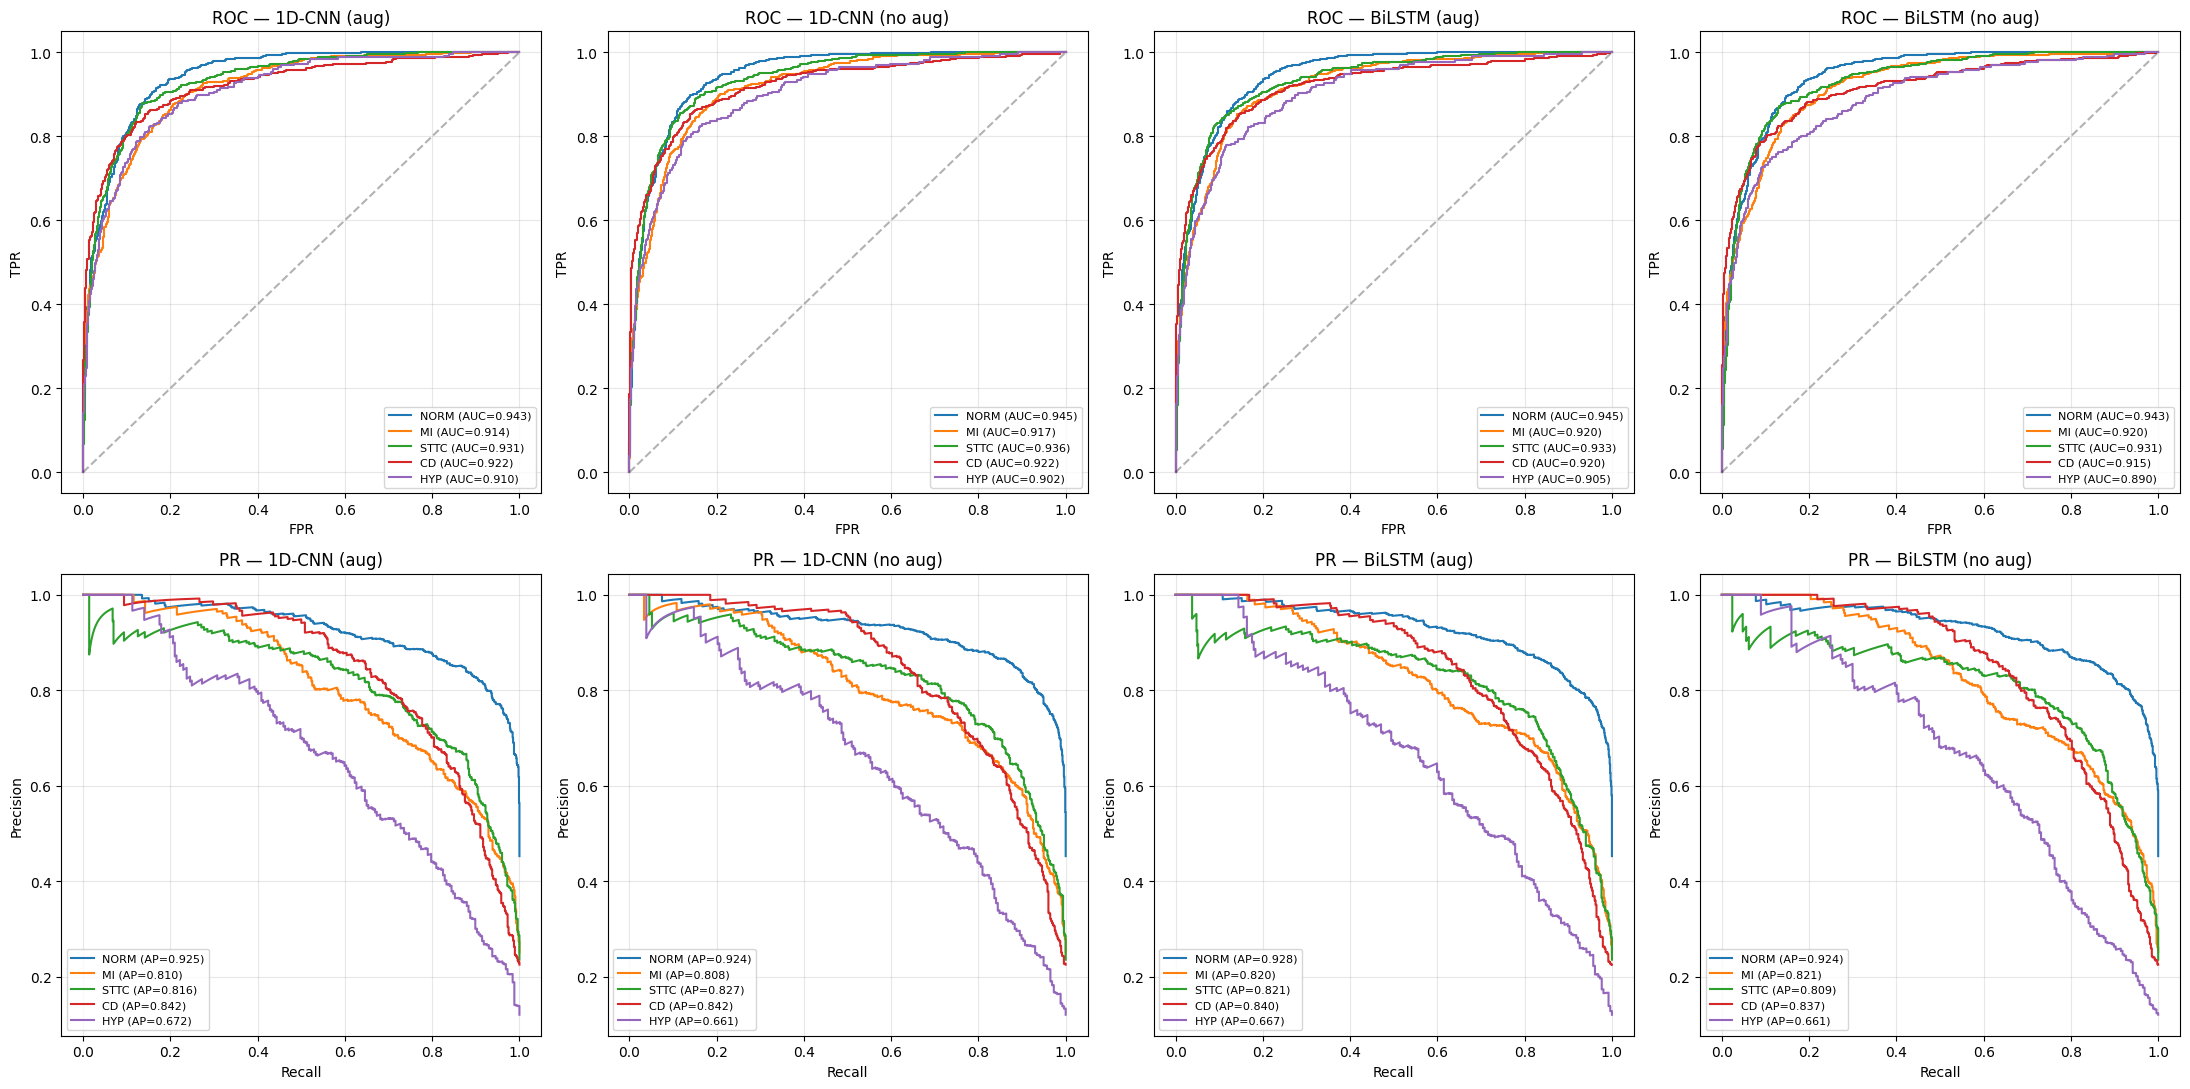

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(22, 11))

# Top row: ROC
for ax, (name, p) in zip(axes[0], probs.items()):
    for i, sc in enumerate(SUPERCLASSES):
        fpr, tpr, _ = roc_curve(y_test[:, i], p[:, i])
        ax.plot(fpr, tpr, label=f"{sc} (AUC={roc_auc_score(y_test[:, i], p[:, i]):.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_title(f"ROC — {MODEL_LABELS[name]}")
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.legend(loc="lower right", fontsize=8); ax.grid(alpha=0.3)

# Bottom row: PR
for ax, (name, p) in zip(axes[1], probs.items()):
    for i, sc in enumerate(SUPERCLASSES):
        prec, rec, _ = precision_recall_curve(y_test[:, i], p[:, i])
        ap = average_precision_score(y_test[:, i], p[:, i])
        ax.plot(rec, prec, label=f"{sc} (AP={ap:.3f})")
    ax.set_title(f"PR — {MODEL_LABELS[name]}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.legend(loc="lower left", fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout(); plt.savefig("roc_pr_curves.png", dpi=150); plt.show()


## 7. Per-class threshold optimisation

The default 0.5 threshold is rarely optimal for multi-label classification
with imbalanced classes. We sweep thresholds in [0.05, 0.95] and pick the
one maximising F1 per class.

**Crucially, the threshold search is done on the validation set** (fold 9),
and the chosen thresholds are then evaluated on the held-out test set
(fold 10). This gives an unbiased estimate of the real-world lift from
threshold tuning.

In [9]:
def find_optimal_thresholds(y_true, y_prob, grid=np.arange(0.05, 0.95, 0.01)):
    thresholds = np.zeros(y_true.shape[1])
    for i in range(y_true.shape[1]):
        f1s = [f1_score(y_true[:, i], (y_prob[:, i] >= t).astype(float),
                        zero_division=0) for t in grid]
        thresholds[i] = grid[int(np.argmax(f1s))]
    return thresholds


# Search on VAL only
optimal_thresholds = {
    name: find_optimal_thresholds(y_val, probs_val[name]) for name in MODEL_NAMES
}

print("Optimal per-class thresholds (selected on validation set):")
print(pd.DataFrame(optimal_thresholds, index=SUPERCLASSES).round(3))

Optimal per-class thresholds (selected on validation set):
      cnn_aug  cnn_noaug  lstm_aug  lstm_noaug
NORM     0.24       0.44      0.51        0.48
MI       0.41       0.35      0.29        0.42
STTC     0.41       0.33      0.37        0.26
CD       0.41       0.26      0.35        0.42
HYP      0.40       0.20      0.23        0.33


In [10]:
# Evaluate on TEST using val-selected thresholds
rows = []
for name, p in probs.items():
    y_pred_05 = (p >= 0.5).astype(np.float32)
    y_pred_opt = np.zeros_like(p)
    for i, t in enumerate(optimal_thresholds[name]):
        y_pred_opt[:, i] = (p[:, i] >= t).astype(np.float32)
    rows.append({
        "model": MODEL_LABELS[name],
        "F1 @ 0.5":        f1_score(y_test, y_pred_05, average="macro", zero_division=0),
        "F1 @ optimised":  f1_score(y_test, y_pred_opt, average="macro", zero_division=0),
        "Δ F1":            f1_score(y_test, y_pred_opt, average="macro", zero_division=0) -
                           f1_score(y_test, y_pred_05, average="macro", zero_division=0),
    })

threshold_gain = pd.DataFrame(rows).set_index("model").round(4)
print("Effect of per-class threshold optimisation on TEST macro-F1")
print("(thresholds selected on val — unbiased estimate):")
display(threshold_gain)

Effect of per-class threshold optimisation on TEST macro-F1
(thresholds selected on val — unbiased estimate):


,F1 @ 0.5,F1 @ optimised,Δ F1
model,,,
1D-CNN (aug),0.7278,0.7402,0.0124
1D-CNN (no aug),0.7291,0.7453,0.0161
BiLSTM (aug),0.7285,0.7427,0.0142
BiLSTM (no aug),0.7306,0.7406,0.0100


## 8. Confusion matrices at optimised thresholds

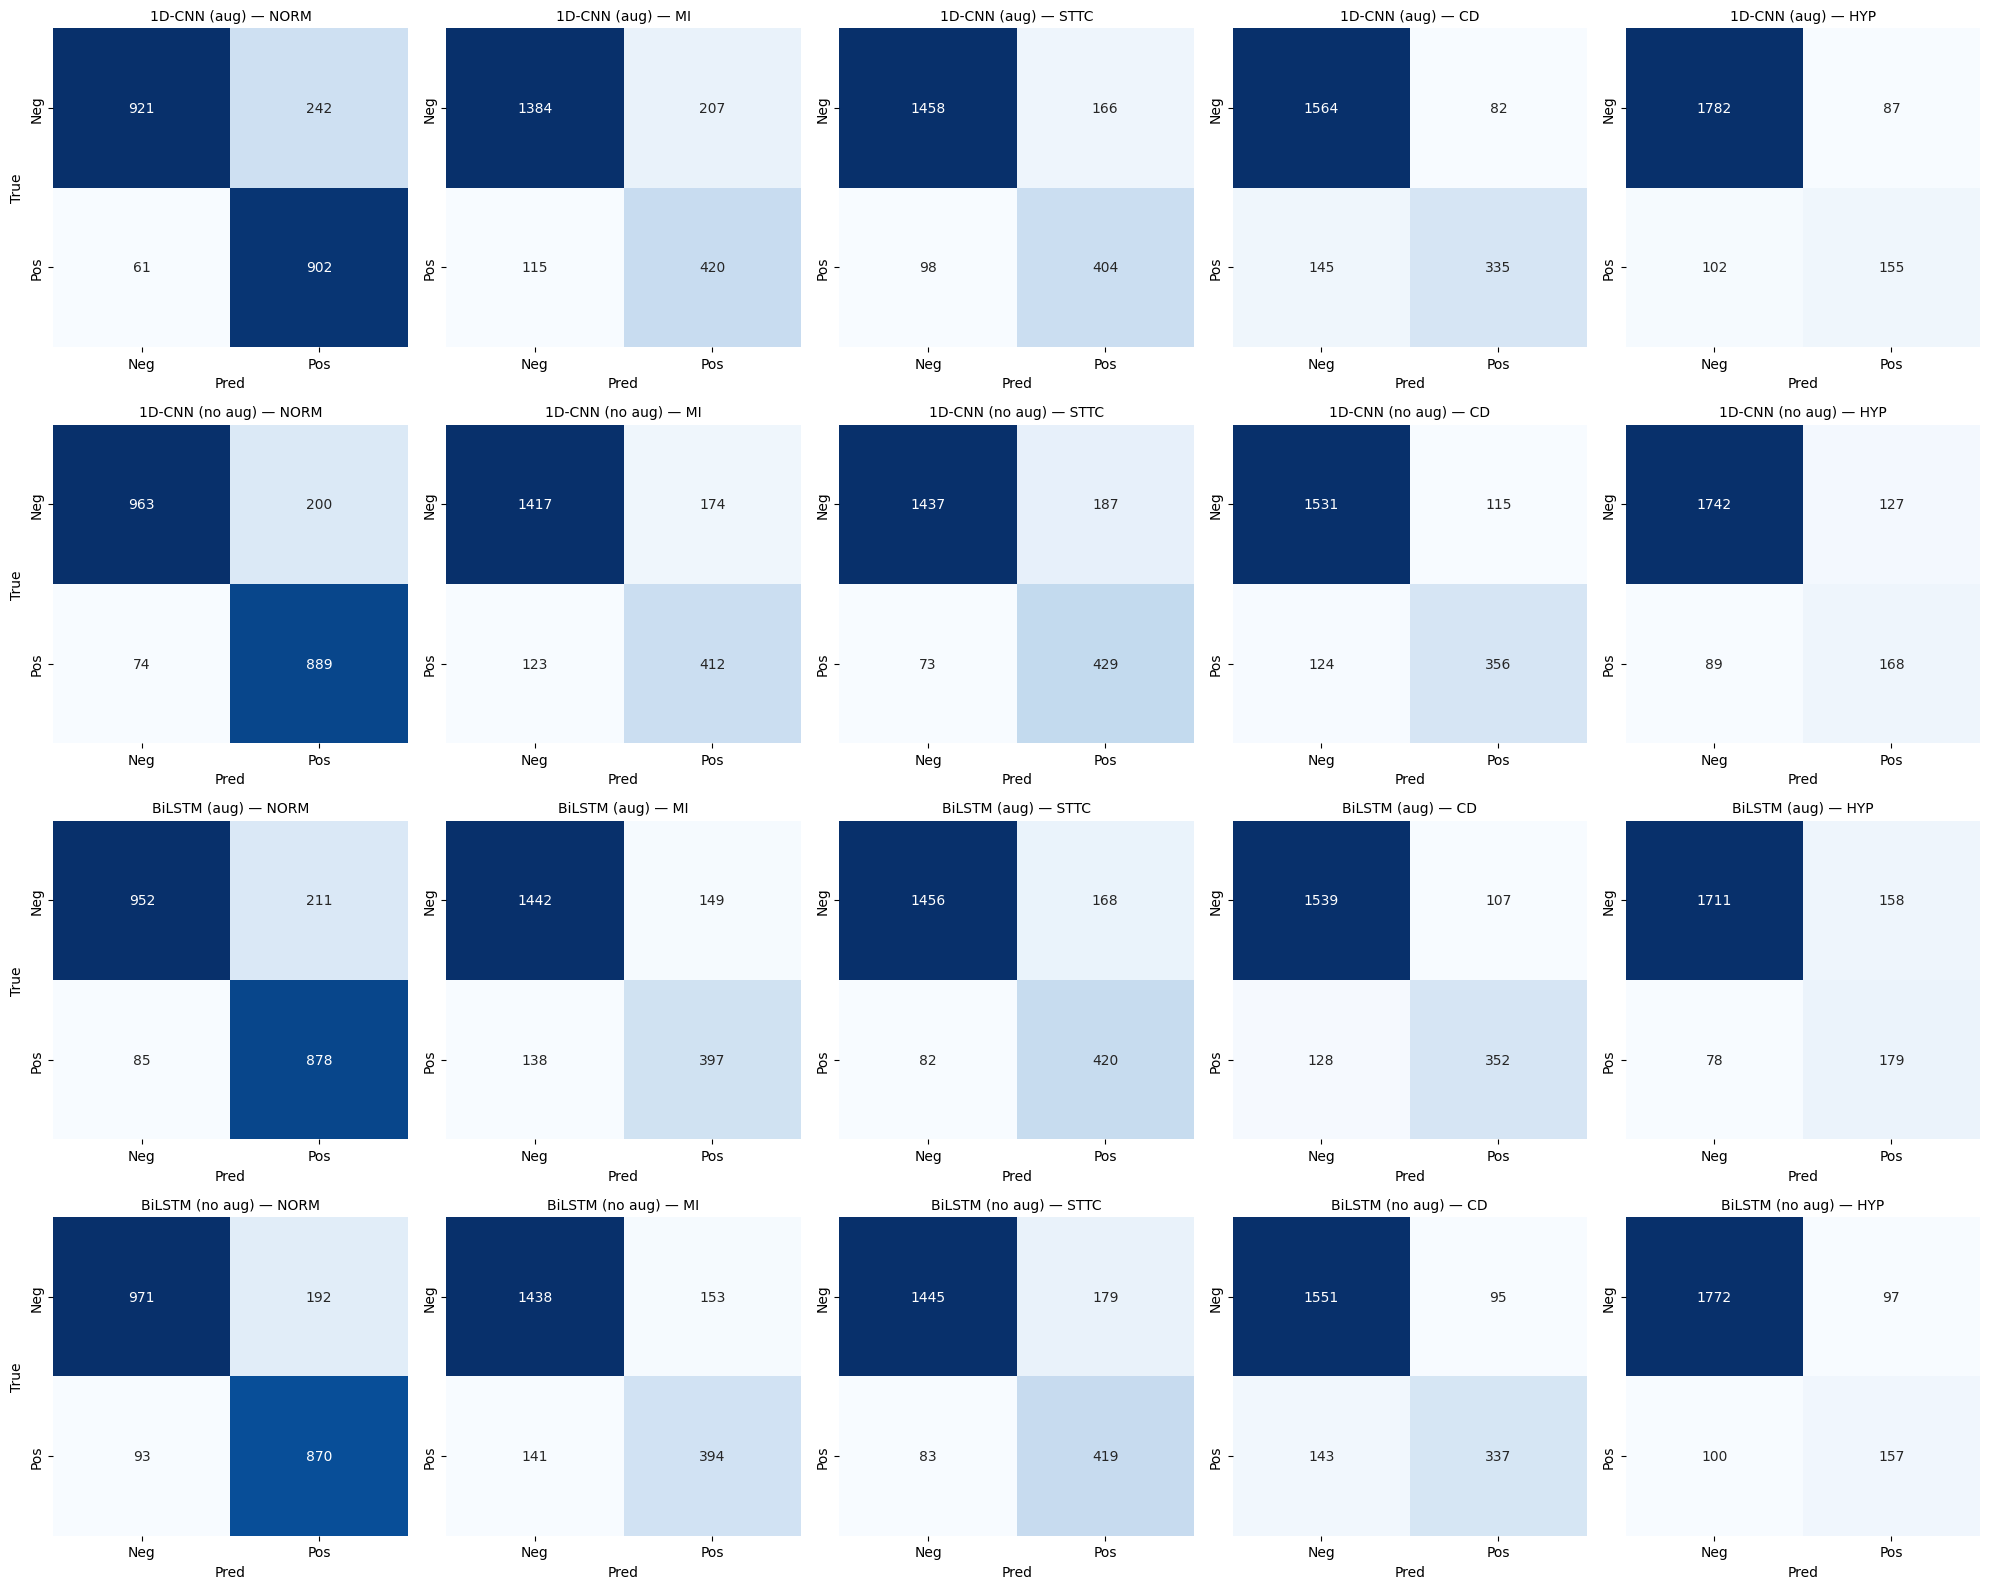

In [11]:
fig, axes = plt.subplots(len(MODEL_NAMES), NUM_CLASSES,
                         figsize=(4 * NUM_CLASSES, 4 * len(MODEL_NAMES)))

def plot_cms(y_pred, row_axes, title):
    cms = multilabel_confusion_matrix(y_test, y_pred)
    for i, (cm, sc, ax) in enumerate(zip(cms, SUPERCLASSES, row_axes)):
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"], cbar=False)
        ax.set_title(f"{title} — {sc}", fontsize=10)
        if i == 0: ax.set_ylabel("True")
        ax.set_xlabel("Pred")

for row, (name, p) in zip(axes, probs.items()):
    y_pred = np.zeros_like(p)
    for i, t in enumerate(optimal_thresholds[name]):
        y_pred[:, i] = (p[:, i] >= t).astype(np.float32)
    plot_cms(y_pred, row, MODEL_LABELS[name])

plt.tight_layout(); plt.savefig("confusion_matrices.png", dpi=150); plt.show()


## 9. Statistical significance — bootstrap confidence intervals

Single-number metrics are misleading without error bars. We bootstrap the
test set (1000 resamples) and report 95% CIs on macro-F1 for each model
at its optimised per-class thresholds.


Bootstrap 95% CIs (1000 resamples):


,F1 mean,95% CI low,95% CI high
model,,,
1D-CNN (aug),0.7396,0.7241,0.7547
1D-CNN (no aug),0.7448,0.7307,0.7598
BiLSTM (aug),0.7421,0.7271,0.7566
BiLSTM (no aug),0.7401,0.7249,0.7558


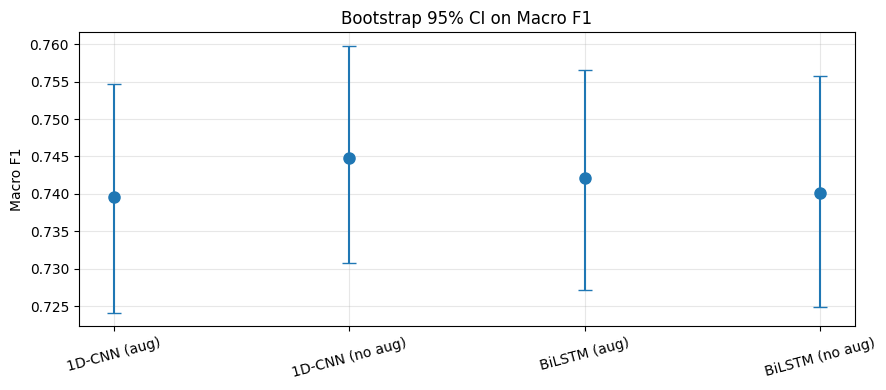

In [12]:
def bootstrap_f1(y_true, y_prob, thresholds, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    scores = np.empty(n_boot)
    y_pred = np.zeros_like(y_prob)
    for i, t in enumerate(thresholds):
        y_pred[:, i] = (y_prob[:, i] >= t).astype(np.float32)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        scores[b] = f1_score(y_true[idx], y_pred[idx],
                             average="macro", zero_division=0)
    return scores.mean(), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


rows = []
for name, p in probs.items():
    mean, lo, hi = bootstrap_f1(y_test, p, optimal_thresholds[name])
    rows.append({"model": MODEL_LABELS[name], "F1 mean": mean,
                 "95% CI low": lo, "95% CI high": hi})

boot_df = pd.DataFrame(rows).set_index("model").round(4)
print("Bootstrap 95% CIs (1000 resamples):")
display(boot_df)

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(boot_df.index, boot_df["F1 mean"],
            yerr=[boot_df["F1 mean"] - boot_df["95% CI low"],
                  boot_df["95% CI high"] - boot_df["F1 mean"]],
            fmt="o", capsize=5, markersize=8)
ax.set_ylabel("Macro F1"); ax.set_title("Bootstrap 95% CI on Macro F1")
ax.grid(alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout(); plt.savefig("bootstrap_ci.png", dpi=150); plt.show()


## 10. Augmentation ablation — paired deltas

Does our augmentation (time shift, Gaussian noise, amplitude scaling) actually help?
We compare each architecture's aug vs no-aug run using a **paired bootstrap**:
the same resampled test indices are used for both runs within each bootstrap
iteration, which cancels dataset-level noise and gives tighter CIs on the delta
than comparing independent CIs.

A 95% CI that excludes zero indicates a statistically significant effect at p<0.05.


In [13]:
def bootstrap_f1_paired(y_true, y_prob_a, y_prob_b,
                        thresholds_a, thresholds_b, n_boot=1000, seed=42):
    """Paired bootstrap — same indices for both runs inside each iteration."""
    rng = np.random.default_rng(seed)
    n = len(y_true)
    y_pred_a = np.zeros_like(y_prob_a)
    y_pred_b = np.zeros_like(y_prob_b)
    for i, t in enumerate(thresholds_a):
        y_pred_a[:, i] = (y_prob_a[:, i] >= t).astype(np.float32)
    for i, t in enumerate(thresholds_b):
        y_pred_b[:, i] = (y_prob_b[:, i] >= t).astype(np.float32)
    scores_a = np.empty(n_boot); scores_b = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        scores_a[b] = f1_score(y_true[idx], y_pred_a[idx],
                               average="macro", zero_division=0)
        scores_b[b] = f1_score(y_true[idx], y_pred_b[idx],
                               average="macro", zero_division=0)
    deltas = scores_a - scores_b
    return scores_a.mean(), scores_b.mean(), deltas.mean(), \
           np.percentile(deltas, 2.5), np.percentile(deltas, 97.5)


ablation_rows = []
for arch in ["cnn", "lstm"]:
    aug_key, noaug_key = f"{arch}_aug", f"{arch}_noaug"
    arch_label = "1D-CNN" if arch == "cnn" else "BiLSTM"
    mean_a, mean_b, delta, lo, hi = bootstrap_f1_paired(
        y_test,
        probs[aug_key],    probs[noaug_key],
        optimal_thresholds[aug_key], optimal_thresholds[noaug_key],
    )
    significant = (lo > 0) or (hi < 0)
    ablation_rows.append({
        "Architecture":  arch_label,
        "F1 aug":        mean_a,
        "F1 no aug":     mean_b,
        "Δ (aug - noaug)": delta,
        "95% CI low":    lo,
        "95% CI high":   hi,
        "p<0.05?":       "yes" if significant else "no",
    })

ablation_df = pd.DataFrame(ablation_rows).set_index("Architecture").round(4)
print("Augmentation ablation — paired bootstrap on macro-F1 at optimised thresholds:")
display(ablation_df)

# Also compute the train-val AUC gap at end of training (overfitting proxy)
gap_rows = []
for arch in ["cnn", "lstm"]:
    for suffix, label in [("aug", "Aug"), ("noaug", "No aug")]:
        key = f"{arch}_{suffix}"
        if key in histories and "auc" in histories[key]:
            train_auc = histories[key]["auc"][-1]
            val_auc   = histories[key]["val_auc"][-1]
            gap_rows.append({
                "Architecture": "1D-CNN" if arch == "cnn" else "BiLSTM",
                "Run":          label,
                "Train AUC":    train_auc,
                "Val AUC":      val_auc,
                "Gap":          train_auc - val_auc,
            })

gap_df = pd.DataFrame(gap_rows).round(4)
print("\nTrain-val AUC gap at end of training (lower = less overfitting):")
display(gap_df)


Augmentation ablation — paired bootstrap on macro-F1 at optimised thresholds:


,F1 aug,F1 no aug,Δ (aug - noaug),95% CI low,95% CI high,p<0.05?
Architecture,,,,,,
1D-CNN,0.7396,0.7448,-0.0052,-0.0154,0.0048,no
BiLSTM,0.7421,0.7401,0.0021,-0.0075,0.0112,no



Train-val AUC gap at end of training (lower = less overfitting):


,Architecture,Run,Train AUC,Val AUC,Gap
0,1D-CNN,Aug,0.9622,0.9234,0.0389
1,1D-CNN,No aug,0.9722,0.9248,0.0474
2,BiLSTM,Aug,0.9617,0.9259,0.0358
3,BiLSTM,No aug,0.9676,0.9208,0.0468


## 11. Grad-CAM on the best single model

Pick the model with the highest bootstrap mean F1 and run Grad-CAM on a few test samples.


In [14]:
# Pick best single model
best_label = boot_df["F1 mean"].idxmax()
best_name  = {v: k for k, v in MODEL_LABELS.items()}[best_label]
best_model = models[best_name]
print(f"Best single model: {best_label}")

# Identify last conv layer name
last_conv_name = None
for layer in reversed(best_model.layers):
    if isinstance(layer, keras.layers.Conv1D):
        last_conv_name = layer.name
        break
print(f"Last conv layer for Grad-CAM: {last_conv_name}")


Best single model: 1D-CNN (no aug)
Last conv layer for Grad-CAM: conv1d_14


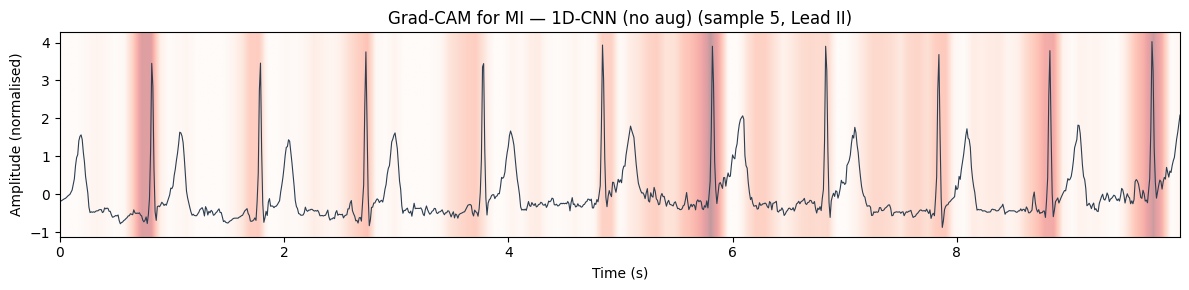

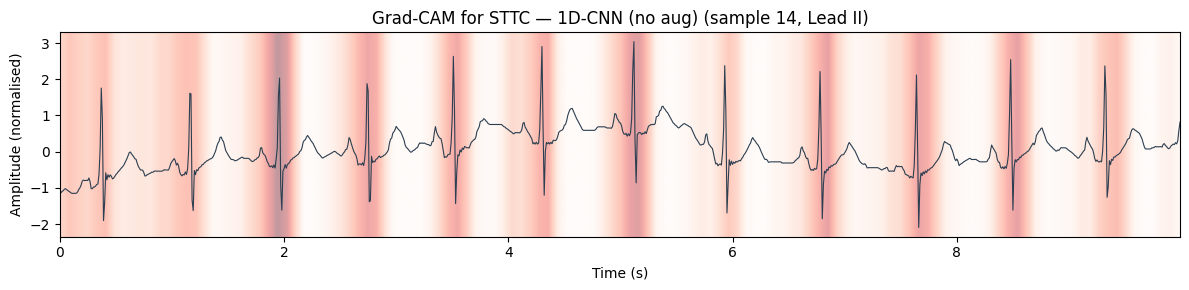

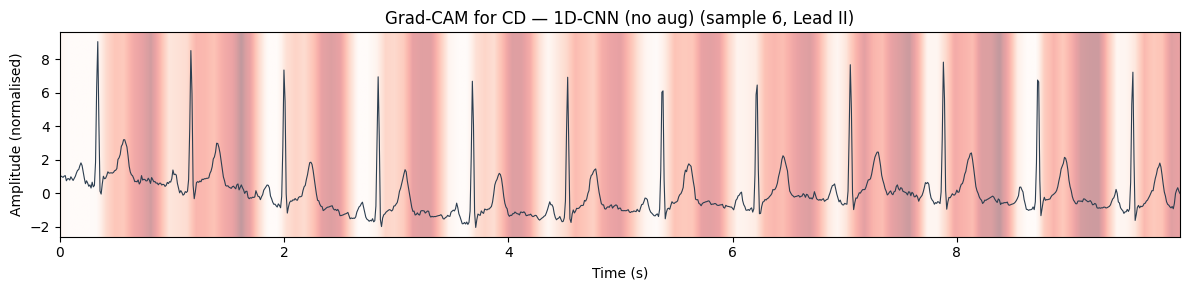

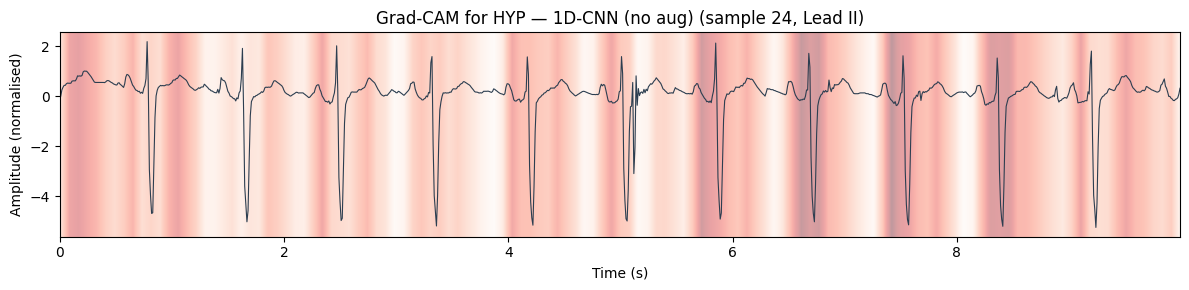

In [15]:
def compute_gradcam_1d(model, input_sample, class_idx, last_conv_name):
    grad_model = keras.Model(inputs=model.input,
                             outputs=[model.get_layer(last_conv_name).output,
                                      model.output])
    x = tf.cast(input_sample, tf.float32)
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(x)
        score = preds[:, class_idx]
    grads = tape.gradient(score, conv_out)
    weights = tf.reduce_mean(grads, axis=1)
    cam = tf.reduce_sum(conv_out * weights[:, tf.newaxis, :], axis=-1)
    cam = tf.nn.relu(cam).numpy().squeeze()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    # Upsample to 1000 samples
    cam = np.interp(np.linspace(0, len(cam) - 1, 1000),
                    np.arange(len(cam)), cam)
    return cam


# Pick samples with clear positive labels for each non-NORM class
LEAD_II = 1
for cls in [1, 2, 3, 4]:  # MI, STTC, CD, HYP
    candidates = np.where(y_test[:, cls] == 1)[0]
    if len(candidates) == 0: continue
    idx = candidates[0]
    sample = X_test[idx:idx+1]
    heatmap = compute_gradcam_1d(best_model, sample, cls, last_conv_name)

    fig, ax = plt.subplots(figsize=(12, 3))
    t = np.arange(1000) / 100
    ax.plot(t, sample[0, :, LEAD_II], color="#2c3e50", linewidth=0.8)
    ax.imshow(heatmap[np.newaxis, :], cmap="Reds", alpha=0.4,
              aspect="auto", extent=[t[0], t[-1], *ax.get_ylim()], origin="lower")
    ax.set_title(f"Grad-CAM for {SUPERCLASSES[cls]} — {best_label} (sample {idx}, Lead II)")
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Amplitude (normalised)")
    plt.tight_layout(); plt.show()

## 12. External benchmark — Strodthoff et al. (2021)

Published macro-AUC results on the PTB-XL superclass task from the reference
benchmarking paper. Same dataset and splits as ours, but trained with a different
pipeline (PyTorch/fastai, 1cycle LR, different initializations and augmentation).

This is **context, not a direct head-to-head comparison** — we cannot conclude
that any specific architectural or training choice caused the numerical
differences. But our results falling within the published range does support the
claim that our models are reasonable implementations of these architectures.


Strodthoff et al. (2021) — super-diagnostic macro-AUC benchmark:


,Macro AUC,CI
Model,,
xresnet1d101,0.925,"[0.920, 0.930]"
resnet1d_wang,0.930,"[0.926, 0.934]"
fcn_wang,0.925,"[0.921, 0.929]"
inception1d,0.921,"[0.916, 0.926]"
lstm_bidir,0.921,"[0.916, 0.926]"
lstm,0.915,"[0.911, 0.919]"
Wavelet+NN,0.849,"[0.842, 0.855]"



Our models (same PTB-XL superclass task):


,Macro AUC
Model,
1D-CNN (aug),0.9240
1D-CNN (no aug),0.9243
BiLSTM (aug),0.9247
BiLSTM (no aug),0.9198


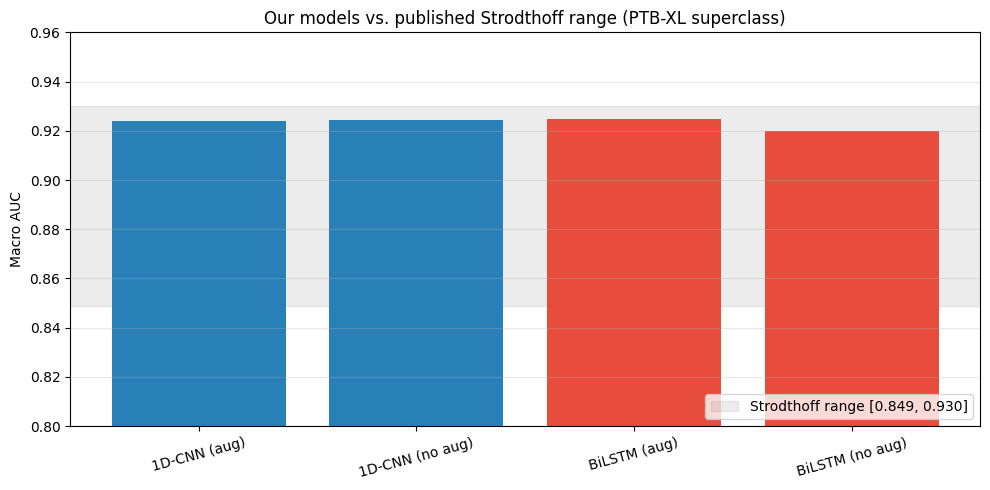

In [16]:
# Published macro-AUC on super-diagnostic task from Strodthoff 2021 Table I
# Source: https://github.com/helme/ecg_ptbxl_benchmarking (leaderboard)
strodthoff_published = pd.DataFrame([
    {"Model": "xresnet1d101",    "Macro AUC": 0.925, "CI": "[0.920, 0.930]"},
    {"Model": "resnet1d_wang",   "Macro AUC": 0.930, "CI": "[0.926, 0.934]"},
    {"Model": "fcn_wang",        "Macro AUC": 0.925, "CI": "[0.921, 0.929]"},
    {"Model": "inception1d",     "Macro AUC": 0.921, "CI": "[0.916, 0.926]"},
    {"Model": "lstm_bidir",      "Macro AUC": 0.921, "CI": "[0.916, 0.926]"},
    {"Model": "lstm",            "Macro AUC": 0.915, "CI": "[0.911, 0.919]"},
    {"Model": "Wavelet+NN",      "Macro AUC": 0.849, "CI": "[0.842, 0.855]"},
]).set_index("Model")

print("Strodthoff et al. (2021) — super-diagnostic macro-AUC benchmark:")
display(strodthoff_published)

# Our results on the same task
our_auc_rows = []
for name, p in probs.items():
    our_auc_rows.append({
        "Model":     MODEL_LABELS[name],
        "Macro AUC": roc_auc_score(y_test, p, average="macro"),
    })
our_auc_df = pd.DataFrame(our_auc_rows).set_index("Model").round(4)

print("\nOur models (same PTB-XL superclass task):")
display(our_auc_df)

# Visual comparison
fig, ax = plt.subplots(figsize=(10, 5))
published_range = (strodthoff_published["Macro AUC"].min(),
                   strodthoff_published["Macro AUC"].max())
ax.axhspan(published_range[0], published_range[1], alpha=0.15, color="gray",
           label=f"Strodthoff range [{published_range[0]:.3f}, {published_range[1]:.3f}]")
for i, (name, row) in enumerate(our_auc_df.iterrows()):
    ax.bar(i, row["Macro AUC"], color="#2980b9" if "CNN" in name else "#e74c3c")
ax.set_xticks(range(len(our_auc_df)))
ax.set_xticklabels(our_auc_df.index, rotation=15)
ax.set_ylabel("Macro AUC")
ax.set_ylim(0.80, 0.96)
ax.set_title("Our models vs. published Strodthoff range (PTB-XL superclass)")
ax.grid(alpha=0.3, axis="y"); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig("strodthoff_context.png", dpi=150); plt.show()


## 13. Final summary

In [17]:
print("=" * 70)
print("  FINAL COMPARISON SUMMARY")
print("=" * 70)

if tuner_results:
    print("\n[Keras Tuner winning config for CNN]")
    for k, v in tuner_results.items():
        print(f"  {k:15s} = {v}")

print("\n[Bootstrap macro-F1 ranking]")
ranking = boot_df.sort_values("F1 mean", ascending=False)
for i, (name, row) in enumerate(ranking.iterrows(), 1):
    print(f"  {i}. {name:20s}  F1 = {row['F1 mean']:.4f}  "
          f"[{row['95% CI low']:.4f}, {row['95% CI high']:.4f}]")

print("\n[Threshold optimisation gain]")
display(threshold_gain)

print("\n[Augmentation ablation]")
display(ablation_df)

n_sig_pos = sum(1 for r in ablation_rows
                if r["p<0.05?"] == "yes" and r["Δ (aug - noaug)"] > 0)
n_sig_neg = sum(1 for r in ablation_rows
                if r["p<0.05?"] == "yes" and r["Δ (aug - noaug)"] < 0)
if n_sig_pos >= 1 and n_sig_neg == 0:
    print(f"  -> Augmentation helps significantly on {n_sig_pos} / {len(ablation_rows)} architectures; keep it.")
elif n_sig_neg > 0:
    print(f"  -> Augmentation HURTS on {n_sig_neg} architecture(s). Consider adjusting.")
else:
    print(f"  -> No significant effect of augmentation. Could be dropped with no accuracy cost.")

print("\n[Recommendation]")
winner = ranking.index[0]
print(f"  Winning model: {winner}")
print(f"  Deploy this to HF Space; update app.py to load the corresponding .keras file.")
print(f"  Use per-class thresholds rather than 0.5 for classification decisions.")
print("=" * 70)


  FINAL COMPARISON SUMMARY

[Keras Tuner winning config for CNN]
  filters_mult    = 2.0
  dropout         = 0.3
  dense_units     = 128
  lr              = 0.0004098521113058352
  loss            = bce

[Bootstrap macro-F1 ranking]
  1. 1D-CNN (no aug)       F1 = 0.7448  [0.7307, 0.7598]
  2. BiLSTM (aug)          F1 = 0.7421  [0.7271, 0.7566]
  3. BiLSTM (no aug)       F1 = 0.7401  [0.7249, 0.7558]
  4. 1D-CNN (aug)          F1 = 0.7396  [0.7241, 0.7547]

[Threshold optimisation gain]


,F1 @ 0.5,F1 @ optimised,Δ F1
model,,,
1D-CNN (aug),0.7278,0.7402,0.0124
1D-CNN (no aug),0.7291,0.7453,0.0161
BiLSTM (aug),0.7285,0.7427,0.0142
BiLSTM (no aug),0.7306,0.7406,0.0100



[Augmentation ablation]


,F1 aug,F1 no aug,Δ (aug - noaug),95% CI low,95% CI high,p<0.05?
Architecture,,,,,,
1D-CNN,0.7396,0.7448,-0.0052,-0.0154,0.0048,no
BiLSTM,0.7421,0.7401,0.0021,-0.0075,0.0112,no


  -> No significant effect of augmentation. Could be dropped with no accuracy cost.

[Recommendation]
  Winning model: 1D-CNN (no aug)
  Deploy this to HF Space; update app.py to load the corresponding .keras file.
  Use per-class thresholds rather than 0.5 for classification decisions.
